In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score


In [54]:
digits = load_digits()

X = digits.data        # shape (1797, 64)
y = digits.target      # labels 0–9



In [55]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [58]:
model_no_pca = LogisticRegression(max_iter=10000)
model_no_pca.fit(X_train, y_train)

y_pred_no_pca = model_no_pca.predict(X_test)
acc_no_pca = accuracy_score(y_test, y_pred_no_pca)

# print("Accuracy without PCA:", acc_no_pca * 100)

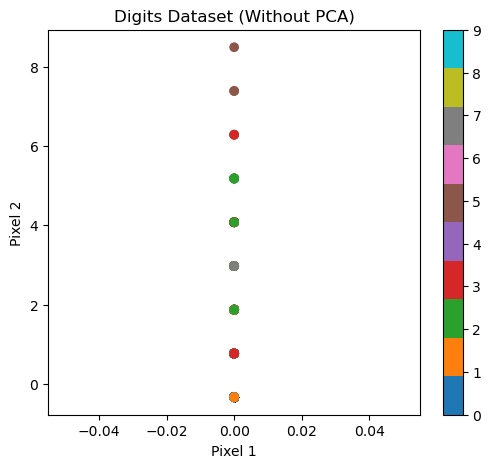

In [59]:
plt.figure(figsize=(6,5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='tab10')
plt.xlabel("Pixel 1")
plt.ylabel("Pixel 2")
plt.title("Digits Dataset (Without PCA)")
plt.colorbar()
plt.show()

In [61]:
pca = PCA(n_components=15)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance:", pca.explained_variance_ratio_.sum())


Explained variance ratio: [0.11802475 0.09578814 0.08353524 0.06328495 0.04920447 0.04397775
 0.03904719 0.03363417 0.03238112 0.02979201 0.02841825 0.02568726
 0.02388308 0.02260186 0.02157253]
Total variance: 0.7108327662195674


In [62]:
model_pca = LogisticRegression(max_iter=10000)
model_pca.fit(X_train_pca, y_train)

y_pred_pca = model_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)

print("Accuracy with PCA:", acc_pca * 100)


Accuracy with PCA: 93.61111111111111


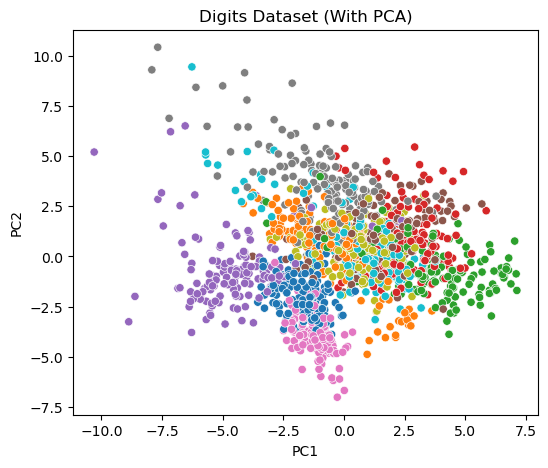

In [63]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    x=X_train_pca[:, 0],
    y=X_train_pca[:, 1],
    hue=y_train,
    palette="tab10",
    legend=False
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Digits Dataset (With PCA)")
plt.show()
